# Customer Segmentation — CLV, RFM & Churn Analysis
### E-Commerce Customer Intelligence | Olist Dataset

In [94]:

!pip install pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

os.makedirs('outputs', exist_ok=True)
print('All libraries imported successfully!')

All libraries imported successfully!


---
## Phase 1 — Load Raw Data

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier 
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score

In [97]:
# Load the 4 Olist CSV files
# Make sure these CSVs are in a 'data/' folder next to this notebook

orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')

print(f'orders    : {len(orders):,} rows')
print(f'items     : {len(items):,} rows')
print(f'customers : {len(customers):,} rows')
print(f'reviews   : {len(reviews):,} rows')

orders    : 99,441 rows
items     : 112,650 rows
customers : 99,441 rows
reviews   : 99,224 rows


In [98]:

orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


---
## Phase 1 — Clean Data (6 Rules)

In [99]:
# Rule 1: Keep only delivered orders 
print('Order status breakdown:')
print(orders['order_status'].value_counts())

orders = orders[orders['order_status'] == 'delivered'].copy()
print(f'\nAfter filter: {len(orders):,} delivered orders')

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

After filter: 96,478 delivered orders


In [100]:
# Rule 2: Parse timestamps → date only 
orders['order_date']    = pd.to_datetime(orders['order_purchase_timestamp']).dt.normalize()
orders['delivery_date'] = pd.to_datetime(orders['order_delivered_customer_date']).dt.normalize()
orders['delivery_days'] = (orders['delivery_date'] - orders['order_date']).dt.days

SNAPSHOT_DATE = orders['order_date'].max()
print(f'Date range    : {orders["order_date"].min().date()} → {orders["order_date"].max().date()}')
print(f'Snapshot date : {SNAPSHOT_DATE.date()}')

Date range    : 2016-09-15 → 2018-08-29
Snapshot date : 2018-08-29


In [101]:
#  Rule 3: Aggregate items → one row per order
order_values = items.groupby('order_id').agg(
    order_value = ('price',         'sum'),
    freight     = ('freight_value', 'sum'),
    item_count  = ('order_item_id', 'count')
).reset_index()

order_values['total_value'] = order_values['order_value'] + order_values['freight']

# Join orders + items
df = orders.merge(order_values, on='order_id', how='left')
print(f'Rows after items join: {len(df):,}  (should match order count)')

Rows after items join: 96,478  (should match order count)


In [102]:
# Rule 4: Join customer_unique_id 
df = df.merge(
    customers[['customer_id','customer_unique_id','customer_city','customer_state']],
    on='customer_id', how='left'
)

print(f'Unique real customers: {df["customer_unique_id"].nunique():,}')
print(f'(vs raw customer_ids: {df["customer_id"].nunique():,})')

Unique real customers: 93,358
(vs raw customer_ids: 96,478)


In [103]:
# Rule 5: LEFT join reviews, fill missing with 3
reviews_clean = reviews.sort_values('review_score', ascending=False) \
                       .drop_duplicates('order_id')[['order_id','review_score']]

df = df.merge(reviews_clean, on='order_id', how='left')
df['review_score'] = df['review_score'].fillna(3).astype(int)

print('Review score distribution:')
print(df['review_score'].value_counts().sort_index())

Review score distribution:
review_score
1     9313
2     2912
3     8546
4    18890
5    56817
Name: count, dtype: int64


In [104]:
#  Rule 6: Add USD + time features 
df['total_value_usd']  = (df['total_value'] / 5.0).round(2)
df['days_since_order'] = (SNAPSHOT_DATE - df['order_date']).dt.days
df['order_month']      = df['order_date'].dt.month
df['order_year']       = df['order_date'].dt.year
df['order_quarter']    = df['order_date'].dt.quarter
df['is_weekend']       = (df['order_date'].dt.dayofweek >= 5).astype(int)

# Drop rows missing critical columns
df = df.dropna(subset=['customer_unique_id','total_value','order_date'])

print(f'Final clean dataset: {len(df):,} rows | {df["customer_unique_id"].nunique():,} customers')
df.head(3)

Final clean dataset: 96,478 rows | 93,358 customers


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,delivery_date,...,customer_unique_id,customer_city,customer_state,review_score,total_value_usd,days_since_order,order_month,order_year,order_quarter,is_weekend
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-02,2017-10-10,...,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4,7.74,331,10,2017,4,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-24,2018-08-07,...,af07308b275d755c9edb36a90c618231,barreiras,BA,4,28.29,36,7,2018,3,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-08,2018-08-17,...,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5,35.82,21,8,2018,3,0


In [105]:
# Save clean master CSV
df.to_csv('olist_clean_master.csv', index=False)
print('olist_clean_master.csv')

olist_clean_master.csv



# Phase 2A — RFM Segmentation

In [106]:
# Compute Recency, Frequency, Monetary per customer
rfm = df.groupby('customer_unique_id').agg(
    last_order_date = ('order_date',  'max'),
    frequency       = ('order_id',    'count'),
    monetary        = ('total_value', 'sum')
).reset_index()

rfm['recency_days']  = (SNAPSHOT_DATE - rfm['last_order_date']).dt.days
rfm['avg_order_val'] = (rfm['monetary'] / rfm['frequency']).round(2)

print(f'Customers: {len(rfm):,}')
rfm.head(3)

Customers: 93,358


,customer_unique_id,last_order_date,frequency,monetary,recency_days,avg_order_val
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,1,141.90,111,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,1,27.19,114,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10,1,86.22,537,86.22


In [107]:
# Score each dimension 1–5
rfm['r_score'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Assign segment label
def assign_segment(score):
    if   score >= 13: return 'Champion'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['segment'] = rfm['rfm_total'].apply(assign_segment)

print('Segment breakdown:')
print(rfm['segment'].value_counts())

Segment breakdown:
segment
Potential    38357
Loyal        31543
At Risk      12245
Champion      8053
Lost          3160
Name: count, dtype: int64


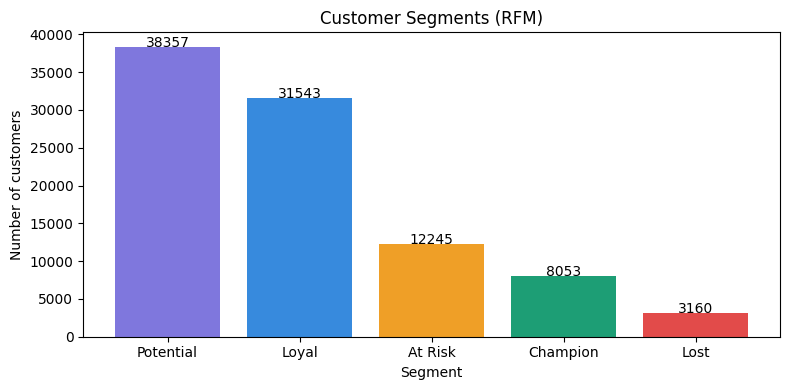

In [108]:
# Plot segment distribution
colors = {'Champion':'#1D9E75','Loyal':'#378ADD','Potential':'#7F77DD','At Risk':'#EF9F27','Lost':'#E24B4A'}
seg_counts = rfm['segment'].value_counts()

plt.figure(figsize=(8,4))
bars = plt.bar(seg_counts.index, seg_counts.values,
               color=[colors.get(s,'gray') for s in seg_counts.index])
plt.title('Customer Segments (RFM)')
plt.xlabel('Segment')
plt.ylabel('Number of customers')
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [109]:
# Save RFM output
rfm[['customer_unique_id','recency_days','frequency','monetary',
     'avg_order_val','r_score','f_score','m_score','rfm_total','segment']] \
    .to_csv('rfm_segments.csv', index=False)

print('rfm_segments.csv')
rfm.head(3)

rfm_segments.csv


,customer_unique_id,last_order_date,frequency,monetary,recency_days,avg_order_val,r_score,f_score,m_score,rfm_total,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,1,141.90,111,141.90,4,1,4,9,Potential
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,1,27.19,114,27.19,4,1,1,6,At Risk
2,0000f46a3911fa3c0805444483337064,2017-03-10,1,86.22,537,86.22,1,1,2,4,Lost


---
## Phase 2B — CLV (Customer Lifetime Value)

In [110]:
# Compute CLV per customer
clv = df.groupby('customer_unique_id').agg(
    total_revenue    = ('total_value',   'sum'),
    frequency        = ('order_id',      'count'),
    first_order      = ('order_date',    'min'),
    last_order       = ('order_date',    'max'),
).reset_index()

# Core metrics
clv['avg_order_value'] = (clv['total_revenue'] / clv['frequency']).round(2)
clv['lifespan_days']   = (clv['last_order'] - clv['first_order']).dt.days
clv['lifespan_years']  = (clv['lifespan_days'] / 365).replace(0, np.nan)
clv['purchase_rate']   = clv['frequency'] / clv['lifespan_years']

# Fill single-order customers with dataset average
avg_rate = clv.loc[clv['frequency'] > 1, 'purchase_rate'].mean()
clv['purchase_rate'] = clv['purchase_rate'].fillna(avg_rate).round(4)

clv['recency_days'] = (SNAPSHOT_DATE - clv['last_order']).dt.days

print(f'Avg purchase rate : {avg_rate:.2f} orders/year')
clv.head(3)

Avg purchase rate : 46.06 orders/year


,customer_unique_id,total_revenue,frequency,first_order,last_order,avg_order_value,lifespan_days,lifespan_years,purchase_rate,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,2018-05-10,2018-05-10,141.90,0,NaN,46.0592,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,2018-05-07,2018-05-07,27.19,0,NaN,46.0592,114
2,0000f46a3911fa3c0805444483337064,86.22,1,2017-03-10,2017-03-10,86.22,0,NaN,46.0592,537


In [111]:
# Predict 12-month CLV
clv['predicted_purchases_12m'] = (clv['purchase_rate'] * 1).round(4)  # 1 = 12/12 months
clv['clv_12m'] = (clv['avg_order_value'] * clv['predicted_purchases_12m']).round(2)

# Cap outliers at 99th percentile
cap = clv['clv_12m'].quantile(0.99)
clv['clv_12m'] = clv['clv_12m'].clip(upper=cap).round(2)

# CLV tier
clv['clv_tier'] = pd.cut(clv['clv_12m'],
    bins=[0, 100, 400, 1000, float('inf')],
    labels=['Low','Medium','High','VIP']
)

print('CLV tier breakdown:')
print(clv['clv_tier'].value_counts())
print(f'\nTotal predicted revenue (12m): R$ {clv["clv_12m"].sum():,.2f}')
print(f'Avg CLV per customer         : R$ {clv["clv_12m"].mean():,.2f}')

CLV tier breakdown:
clv_tier
VIP       91760
High       1165
Medium      418
Low          15
Name: count, dtype: int64

Total predicted revenue (12m): R$ 660,956,743.95
Avg CLV per customer         : R$ 7,079.81


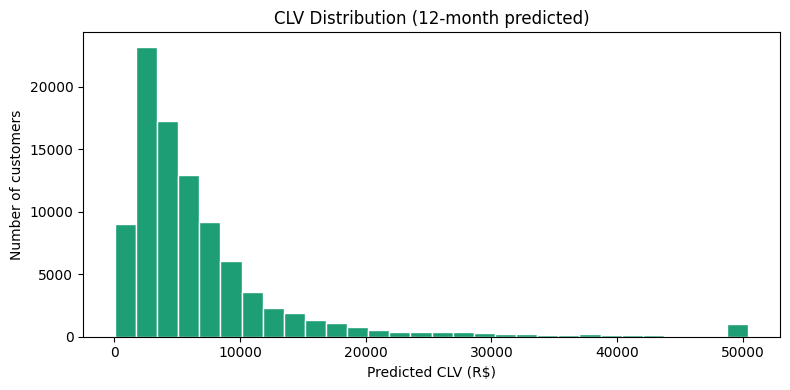

In [112]:
# Plot CLV distribution
plt.figure(figsize=(8,4))
plt.hist(clv['clv_12m'], bins=30, color='#1D9E75', edgecolor='white')
plt.title('CLV Distribution (12-month predicted)')
plt.xlabel('Predicted CLV (R$)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

In [113]:
# Save CLV output
clv[['customer_unique_id','frequency','total_revenue','avg_order_value',
     'recency_days','lifespan_days','purchase_rate',
     'predicted_purchases_12m','clv_12m','clv_tier']] \
    .to_csv('clv_scores.csv', index=False)

print('clv_scores.csv')
clv.head(3)

clv_scores.csv


,customer_unique_id,total_revenue,frequency,first_order,last_order,avg_order_value,lifespan_days,lifespan_years,purchase_rate,recency_days,predicted_purchases_12m,clv_12m,clv_tier
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,2018-05-10,2018-05-10,141.90,0,NaN,46.0592,111,46.0592,6535.80,VIP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,2018-05-07,2018-05-07,27.19,0,NaN,46.0592,114,46.0592,1252.35,VIP
2,0000f46a3911fa3c0805444483337064,86.22,1,2017-03-10,2017-03-10,86.22,0,NaN,46.0592,537,46.0592,3971.22,VIP


---
## Phase 2C — Churn Prediction

In [114]:
# Build customer feature table
features = df.groupby('customer_unique_id').agg(
    total_orders     = ('order_id',      'count'),
    total_revenue    = ('total_value',   'sum'),
    avg_order_value  = ('total_value',   'mean'),
    avg_review       = ('review_score',  'mean'),
    avg_delivery     = ('delivery_days', 'mean'),
    total_items      = ('item_count',    'sum'),
    last_order_date  = ('order_date',    'max'),
    first_order_date = ('order_date',    'min'),
    weekend_orders   = ('is_weekend',    'sum'),
).reset_index()

features['recency_days']     = (SNAPSHOT_DATE - features['last_order_date']).dt.days
features['lifespan_days']    = (features['last_order_date'] - features['first_order_date']).dt.days
features['weekend_ratio']    = (features['weekend_orders'] / features['total_orders']).round(4)
features['revenue_per_item'] = (features['total_revenue'] / features['total_items']).round(2)

# Merge RFM scores
features = features.merge(
    rfm[['customer_unique_id','r_score','f_score','m_score','rfm_total','segment']],
    on='customer_unique_id', how='left'
)

le = LabelEncoder()
features['segment_enc'] = le.fit_transform(features['segment'].fillna('Unknown'))

print(f'Feature table: {len(features):,} customers × {len(features.columns)} columns')

Feature table: 93,358 customers × 20 columns


In [115]:
# Define churn label — inactive > 90 days = churned
CHURN_DAYS = 90
features['churned'] = (features['recency_days'] > CHURN_DAYS).astype(int)

print(f'Churn rate : {features["churned"].mean()*100:.1f}%')
print(f'Churned    : {features["churned"].sum():,}')
print(f'Active     : {(features["churned"]==0).sum():,}')

Churn rate : 80.2%
Churned    : 74,838
Active     : 18,520


In [116]:

# ============================================================
# CUSTOMER CHURN PREDICTION (
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

# ============================================================
# 1. CREATE TARGET
# ============================================================

CHURN_DAYS = 90

features['churned'] = (
    features['recency_days'] > CHURN_DAYS
).astype(int)

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

features['orders_per_day'] = (
    features['total_orders'] /
    (features['lifespan_days'] + 1)
)

features['orders_per_month'] = (
    features['total_orders'] /
    ((features['lifespan_days'] / 30) + 1)
)

features['revenue_per_day'] = (
    features['total_revenue'] /
    (features['lifespan_days'] + 1)
)

features['revenue_per_order'] = (
    features['total_revenue'] /
    features['total_orders'].clip(lower=1)
)

features['avg_days_between_orders'] = (
    features['lifespan_days'] /
    features['total_orders'].clip(lower=1)
)

features['items_per_order'] = (
    features['total_items'] /
    features['total_orders'].clip(lower=1)
)

features['review_x_orders'] = (
    features['avg_review'] *
    features['total_orders']
)

features['delivery_x_review'] = (
    features['avg_delivery'].fillna(0) *
    features['avg_review']
)

features['log_revenue'] = np.log1p(
    features['total_revenue']
)

features['log_lifespan'] = np.log1p(
    features['lifespan_days']
)

features['is_single_order'] = (
    features['total_orders'] == 1
).astype(int)

# ============================================================
# 3. REMOVE LEAKAGE FEATURES
# ============================================================

DROP_COLS = [
    'recency_days',
    'r_score',
    'rfm_total',
    'segment',
    'segment_enc',
    'churn_probability',
    'churn_risk',
    'last_order_date',
    'first_order_date'
]

features_model = features.drop(
    columns=DROP_COLS,
    errors='ignore'
)

FEATURE_COLS = [
    'total_orders',
    'total_revenue',
    'avg_order_value',
    'avg_review',
    'avg_delivery',
    'lifespan_days',
    'weekend_ratio',
    'revenue_per_item',
    'f_score',
    'm_score',
    'orders_per_day',
    'orders_per_month',
    'revenue_per_day',
    'revenue_per_order',
    'avg_days_between_orders',
    'items_per_order',
    'review_x_orders',
    'delivery_x_review',
    'log_revenue',
    'log_lifespan',
    'is_single_order'
]

X = features_model[FEATURE_COLS].fillna(0)
y = features_model['churned']

print("Dataset Shape:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())

# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 5. CLASS WEIGHT
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

print("\nScale Pos Weight:", scale_pos_weight)

# ============================================================
# 6. XGBOOST MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 7. PREDICTIONS
# ============================================================

y_prob = model.predict_proba(X_test)[:,1]

BEST_THRESHOLD = 0.26
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

# ============================================================
# 8. EVALUATION
# ============================================================

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Active','Churned']
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print("\nTop Features")
print(importance.head(15))

# ============================================================
# 10. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(
    f"\n5-Fold ROC-AUC: "
    f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
)

# ============================================================
# 11. CHURN PROBABILITY
# ============================================================

features['churn_probability'] = (
    model.predict_proba(X)[:,1]
).round(4)

features['churn_risk'] = pd.cut(
    features['churn_probability'],
    bins=[0,0.4,0.7,1.0],
    labels=['Low','Medium','High']
)

print("\nRisk Breakdown:")
print(features['churn_risk'].value_counts())



Dataset Shape: (93358, 21)

Class Distribution:
churned
1    74838
0    18520
Name: count, dtype: int64

Scale Pos Weight: 0.24746951728745614

MODEL PERFORMANCE
Accuracy : 0.8032
ROC-AUC  : 0.7211

Classification Report
              precision    recall  f1-score   support

      Active       0.54      0.06      0.10      3704
     Churned       0.81      0.99      0.89     14968

    accuracy                           0.80     18672
   macro avg       0.67      0.52      0.49     18672
weighted avg       0.76      0.80      0.73     18672


Confusion Matrix
[[  204  3500]
 [  174 14794]]

Top Features
                    Feature  Importance
4              avg_delivery    0.174718
9                   m_score    0.063024
11         orders_per_month    0.056612
7          revenue_per_item    0.052704
17        delivery_x_review    0.049751
12          revenue_per_day    0.049662
13        revenue_per_order    0.049609
18              log_revenue    0.047899
10           orders_per_day  

In [117]:
from sklearn.metrics import accuracy_score
import numpy as np

best_acc = 0
best_threshold = 0

for t in np.arange(0.1, 0.95, 0.01):
    preds = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("Best Accuracy :", round(best_acc,4))
print("Best Threshold:", round(best_threshold,2))

Best Accuracy : 0.8032
Best Threshold: 0.26


In [118]:
# Save churn output (uses ensemble_proba written in previous cell)
features[['customer_unique_id','churned','churn_probability',
          'churn_risk','recency_days','total_orders','total_revenue','avg_review']] \
    .to_csv('outputs/churn_scores.csv', index=False)

print('churn_scores.csv')
features.head(3)


churn_scores.csv


,customer_unique_id,total_orders,total_revenue,avg_order_value,avg_review,avg_delivery,total_items,last_order_date,first_order_date,weekend_orders,...,revenue_per_order,avg_days_between_orders,items_per_order,review_x_orders,delivery_x_review,log_revenue,log_lifespan,is_single_order,churn_probability,churn_risk
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,1,2018-05-10,2018-05-10,0,...,141.90,0.0,1.0,5.0,30.0,4.962145,0.0,1,0.2885,Low
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,1,2018-05-07,2018-05-07,0,...,27.19,0.0,1.0,4.0,12.0,3.338967,0.0,1,0.4296,Medium
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,26.0,1,2017-03-10,2017-03-10,0,...,86.22,0.0,1.0,3.0,78.0,4.468434,0.0,1,0.8436,High


---
## Final Summary

In [120]:
print('=' * 50)
print('  PROJECT COMPLETE')
print('=' * 50)
print(f'  Total customers analysed : {len(rfm):,}')
print(f'  Total orders processed   : {len(df):,}')
print(f'  Champions identified     : {(rfm["segment"]=="Champion").sum():,}')
print(f'  Predicted revenue (12m)  : R$ {clv["clv_12m"].sum():,.2f}')
print(f'  High churn risk customers: {(features["churn_risk"]=="High").sum():,}')
print()
print('  Output files saved to outputs/:')
print('    olist_clean_master.csv')
print('    rfm_segments.csv')
print('    clv_scores.csv')
print('    churn_scores.csv')



  PROJECT COMPLETE
  Total customers analysed : 93,358
  Total orders processed   : 96,478
  Champions identified     : 8,053
  Predicted revenue (12m)  : R$ 660,956,743.95
  High churn risk customers: 24,885

  Output files saved to outputs/:
    olist_clean_master.csv
    rfm_segments.csv
    clv_scores.csv
    churn_scores.csv
